<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

In [8]:
!pip install datasets

In [9]:
!pip install transformers

In [10]:
!pip install evaluate

### Загрузим датасет

In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from datasets import load_dataset,Dataset

In [12]:
url = "https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/export?format=csv&gid=661202001"
df = pd.read_csv(url).drop(columns=['Unnamed: 0']).dropna()

df.head()


,problem_text,topic
0,To prove that the sum of the numbers of the ex...,number_theory
1,( b) Will the statement of the previous challe...,number_theory
2,The quadratic three-member graph with the coef...,polynoms
3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,"Dima, who came from Vrunlandia, said that ther...",graphs


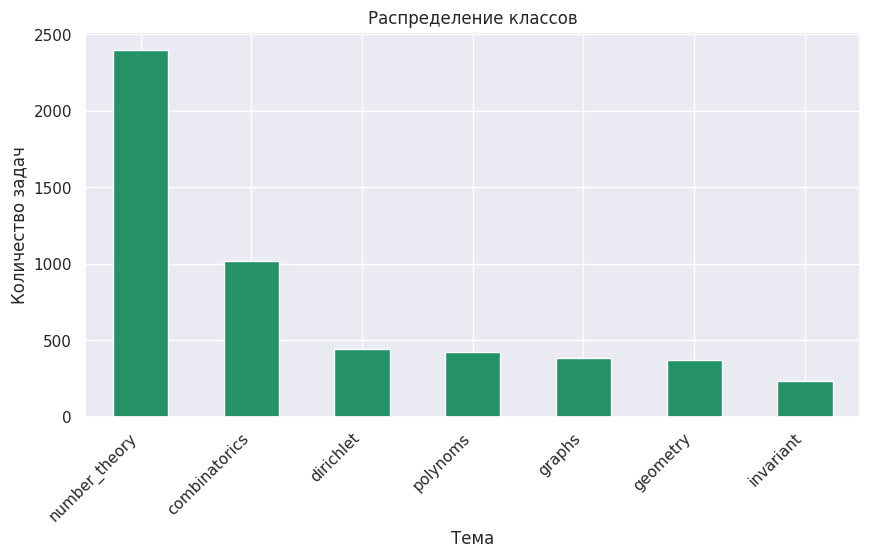

In [191]:
class_counts = df['topic'].value_counts()

plt.figure(figsize=(10, 5))
class_counts.plot(kind='bar')
plt.title('Распределение классов')
plt.xlabel('Тема')
plt.ylabel('Количество задач')
plt.xticks(rotation=45, ha='right')
plt.show()

In [194]:
X = df['problem_text']
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['topic'])

num_classes = df['topic'].nunique()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [155]:
train_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train})).remove_columns("__index_level_0__")
test_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_test, 'label': y_test})).remove_columns("__index_level_0__")
dataset = Dataset.from_pandas(pd.DataFrame({'text': X, 'label': y}))

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [127]:
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(palette='summer')

from transformers import AutoModel, AutoConfig,AutoTokenizer
from sklearn.metrics import accuracy_score

In [16]:
import transformers
import evaluate

In [17]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [18]:
### This is just an interface example. You may change it if you want.

class TransformerClassificationModel(nn.Module):
    def __init__(self,base_transformer_model:str, num_classes: int):

      super().__init__()

      self.config = AutoConfig.from_pretrained(base_transformer_model)
      self.backbone = AutoModel.from_pretrained(base_transformer_model)

      hidden_size = self.config.hidden_size


      self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_size, num_classes)
        )
      self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):

      outputs = self.backbone(
        input_ids=input_ids,
        return_dict=True
    )
      cls_output = outputs.last_hidden_state[:, 0, :]
      logits = self.classifier(cls_output)

      loss = None
      if labels is not None:
        loss = self.loss_fn(logits, labels)

      return {"loss": loss, "logits": logits}

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [106]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

In [201]:
tokenizer = AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')

In [200]:
def preprocess_function(examples, tokenizer = tokenizer):
    return tokenizer(examples["text"], padding="max_length",
                     truncation=True, max_length=256)

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [203]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

In [202]:
import copy

def train_transformer(transformer_model, freeze_backbone=True, num_train_epochs = 10):
    model = copy.copy(transformer_model)
    if freeze_backbone:
        model =freeze_backbone_function(model)

    training_args = transformers.TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        learning_rate=5e-4,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=64,
        num_train_epochs=num_train_epochs,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        report_to='none'
        )
    trainer = transformers.Trainer(
      model=model,
      args=training_args,
      train_dataset=train_dataset,
      eval_dataset=test_dataset,
      compute_metrics=compute_metrics
      )
    trainer.train()

    return model

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [204]:
tokenizer = AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')

In [211]:
train_dataset = train_dataset.map(lambda examples: preprocess_function(examples, tokenizer), batched=True)
test_dataset = test_dataset.map(lambda examples: preprocess_function(examples, tokenizer), batched=True)


Map:   0%|          | 0/4218 [00:00<?, ? examples/s]

Map:   0%|          | 0/1055 [00:00<?, ? examples/s]

In [206]:
rubert_tiny_transformer_model = TransformerClassificationModel(base_transformer_model="cointegrated/rubert-tiny2",
                                       num_classes=len(label_encoder.classes_))
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(rubert_tiny_transformer_model, freeze_backbone=True, num_train_epochs = 10)

Epoch,Training Loss,Validation Loss,Accuracy
1,1.611700,1.533113,0.461611
2,1.535100,1.496987,0.470142
3,1.505000,1.481193,0.471090
4,1.488600,1.462163,0.472038
5,1.476000,1.451922,0.477725
6,1.464500,1.442854,0.485308
7,1.461400,1.435868,0.486256
8,1.455000,1.432121,0.484360
9,1.451100,1.429434,0.487204
10,1.448100,1.428453,0.487204


In [165]:
rubert_tiny_transformer_model = TransformerClassificationModel(base_transformer_model="cointegrated/rubert-tiny2",
                                       num_classes=len(label_encoder.classes_))
rubert_tiny_finetuned = train_transformer(rubert_tiny_transformer_model, freeze_backbone=False,num_train_epochs = 2)

Epoch,Training Loss,Validation Loss,Accuracy
1,1.218200,1.012918,0.600948
2,0.889700,0.971768,0.615166


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [217]:
tokenizer = AutoTokenizer.from_pretrained("tbs17/MathBERT")

In [218]:
train_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train})).remove_columns("__index_level_0__")
test_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_test, 'label': y_test})).remove_columns("__index_level_0__")

In [219]:
train_dataset = train_dataset.map(lambda examples: preprocess_function(examples, tokenizer), batched=True)
test_dataset = test_dataset.map(lambda examples: preprocess_function(examples, tokenizer), batched=True)

Map:   0%|          | 0/4218 [00:00<?, ? examples/s]

Map:   0%|          | 0/1055 [00:00<?, ? examples/s]

In [176]:
mathbert_model = TransformerClassificationModel(base_transformer_model="tbs17/MathBERT",
                                       num_classes=len(label_encoder.classes_))
mathbert_finetuned_with_freezed_backbone = train_transformer(mathbert_model, freeze_backbone=True, num_train_epochs = 20)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.630600,1.504618,0.484360
2,1.516100,1.495011,0.486256
3,1.476200,1.428053,0.488152
4,1.441100,1.403951,0.492891
5,1.425400,1.413962,0.490995
6,1.413300,1.373519,0.496682
7,1.393700,1.383342,0.494787
8,1.382100,1.351683,0.496682
9,1.368600,1.345514,0.498578
10,1.352200,1.353871,0.498578


In [186]:
mathbert_model = None

In [187]:
mathbert_model = TransformerClassificationModel(base_transformer_model="tbs17/MathBERT",
                                       num_classes=len(label_encoder.classes_))
mathbert_finetuned = train_transformer(mathbert_model, freeze_backbone=False,num_train_epochs = 2)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.870500,1.621566,0.454976
2,1.646100,1.605421,0.454976


Модели с размороженным бекбоуном сколнны к переобучению - пришлось уменьшить число эпох

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [120]:
from typing import Union, Dict, List

def draw_first_layer_attention_maps(
    attention_head_ids,
    text,
    model,
    model_name,
    figsize=(10, 16)
):
    device = next(model.parameters()).device  # Определяем, где находится модель
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    input_ids = inputs["input_ids"]

    with torch.no_grad():
        outputs = model.backbone(**inputs, output_attentions=True)

    attentions = outputs.attentions[0][0].detach().cpu()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())

    fig, axes = plt.subplots(ncols=len(attention_head_ids), figsize=figsize)
    if len(attention_head_ids) == 1:
        axes = [axes]

    for i, head_id in enumerate(attention_head_ids):
        ax = axes[i]
        attention_weights = attentions[head_id].numpy()

        valid_indices = [
            i for i, token in enumerate(tokens)
            if token not in ["[CLS]", "[SEP]", "[PAD]"]
        ]
        filtered_weights = attention_weights[np.ix_(valid_indices, valid_indices)]
        filtered_tokens = [tokens[i] for i in valid_indices]

        im = ax.imshow(filtered_weights, cmap='viridis')
        ax.set_xticks(range(len(filtered_tokens)))
        ax.set_yticks(range(len(filtered_tokens)))
        ax.set_xticklabels(filtered_tokens, rotation=90)
        ax.set_yticklabels(filtered_tokens)
        ax.grid(False)
        ax.set_title(f"Head # {head_id}")

    plt.tight_layout()
    plt.show()


### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

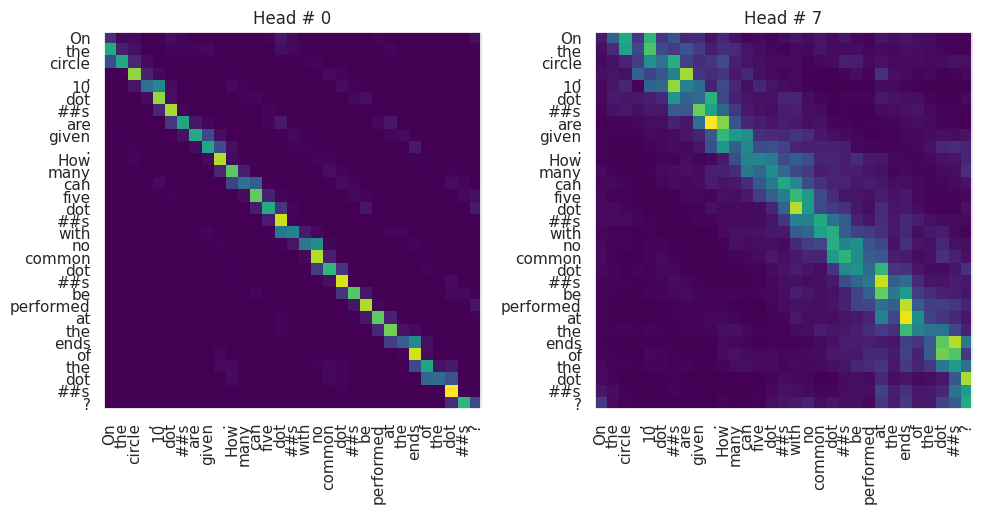

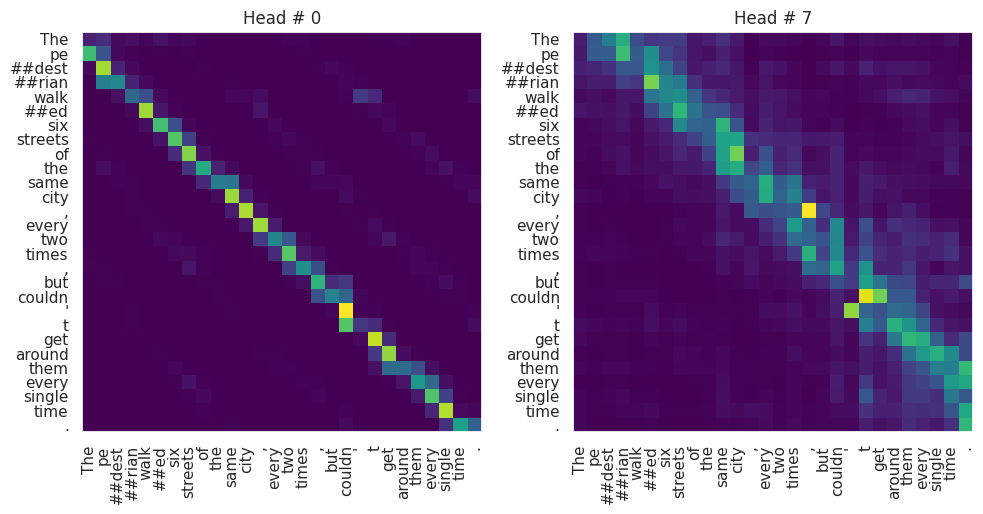

In [121]:
text1 = test_dataset['text'][3]
text2 = test_dataset['text'][4]
model = TransformerClassificationModel("cointegrated/rubert-tiny2", num_classes=len(label_encoder.classes_))

draw_first_layer_attention_maps([0, 7], text1, model, "cointegrated/rubert-tiny2")
draw_first_layer_attention_maps([0, 7], text2, model, "cointegrated/rubert-tiny2")

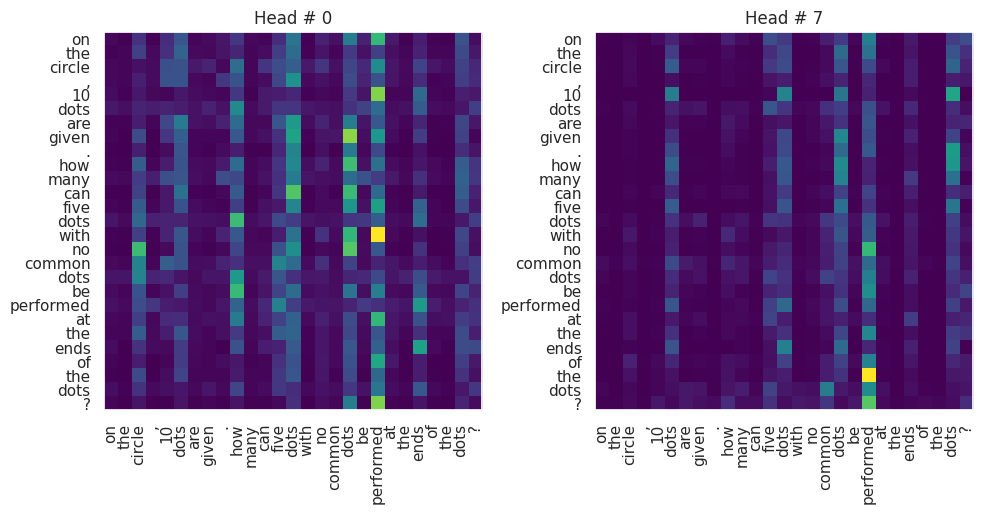

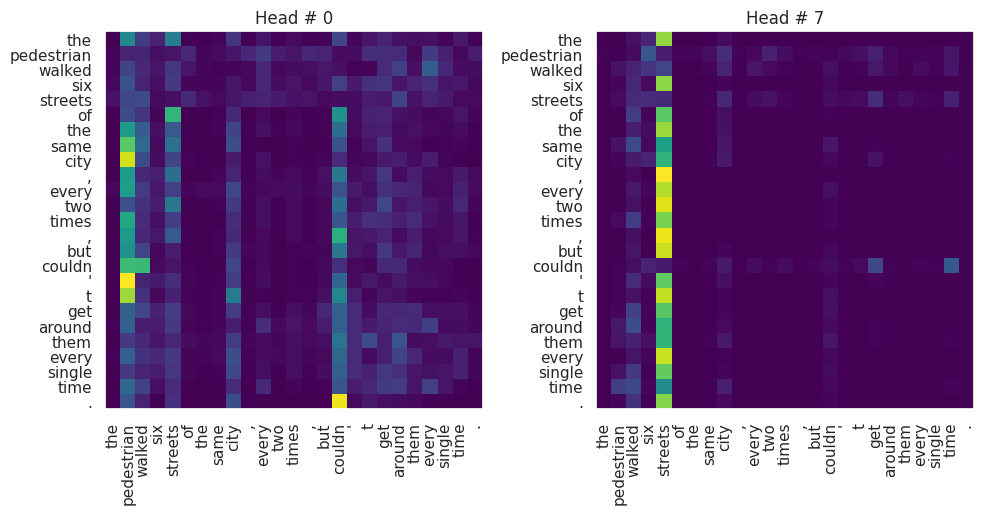

In [122]:
text1 = test_dataset['text'][3]
text2 = test_dataset['text'][4]
model = TransformerClassificationModel("tbs17/MathBert", num_classes=len(label_encoder.classes_))

draw_first_layer_attention_maps([0, 7], text1, model, "tbs17/MathBert")
draw_first_layer_attention_maps([0, 7], text2, model, "tbs17/MathBert")

RuBert в основном обращает внимание на соседние токены, когда MathBert выявляет более сложные зависимости

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

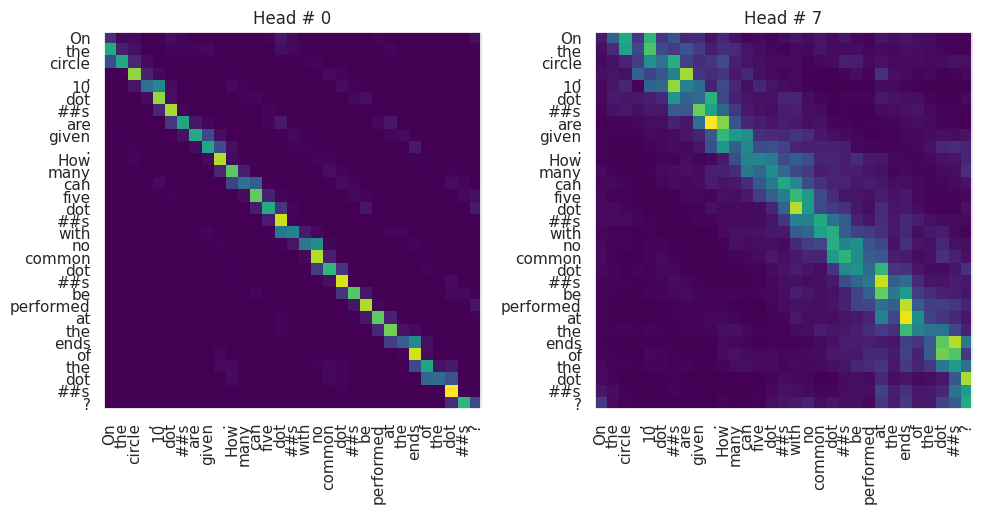

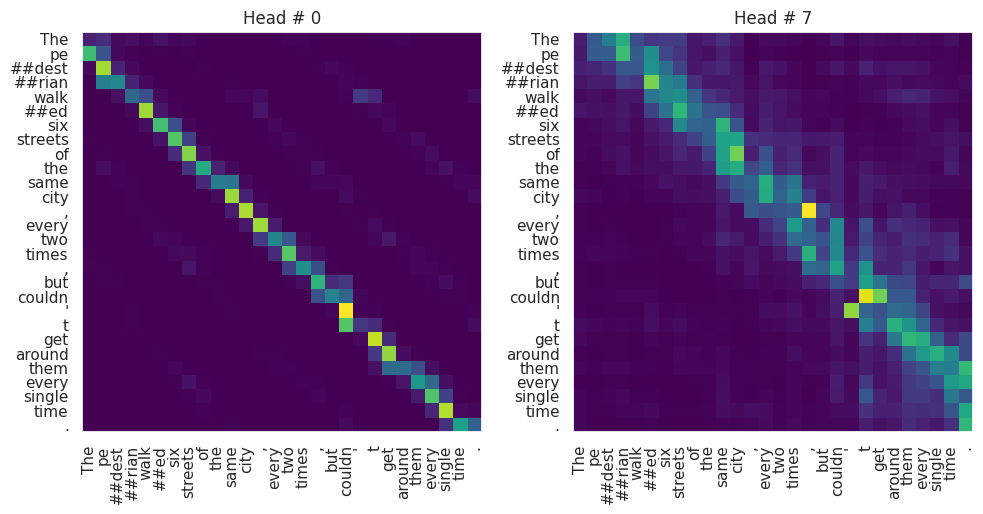

In [123]:
text1 = test_dataset['text'][3]
text2 = test_dataset['text'][4]
model = rubert_tiny_finetuned_with_freezed_backbone

draw_first_layer_attention_maps([0, 7], text1, model, "cointegrated/rubert-tiny2")
draw_first_layer_attention_maps([0, 7], text2, model, "cointegrated/rubert-tiny2")

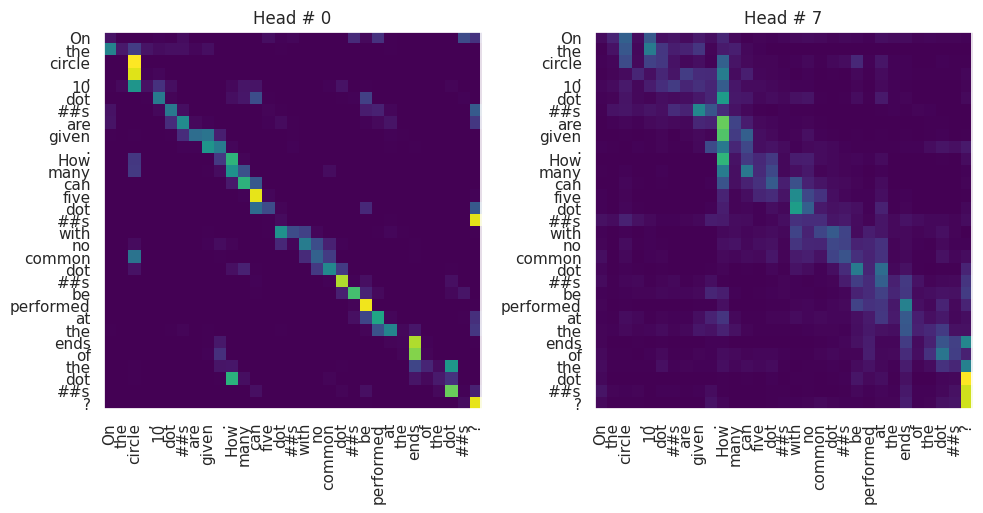

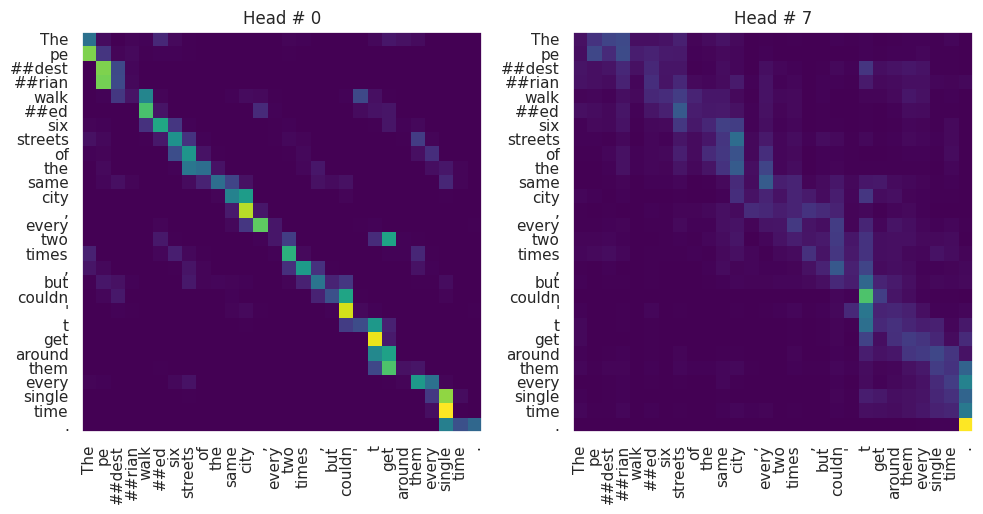

In [124]:
text1 = test_dataset['text'][3]
text2 = test_dataset['text'][4]
model = rubert_tiny_finetuned

draw_first_layer_attention_maps([0, 7], text1, model, "cointegrated/rubert-tiny2")
draw_first_layer_attention_maps([0, 7], text2, model, "cointegrated/rubert-tiny2")

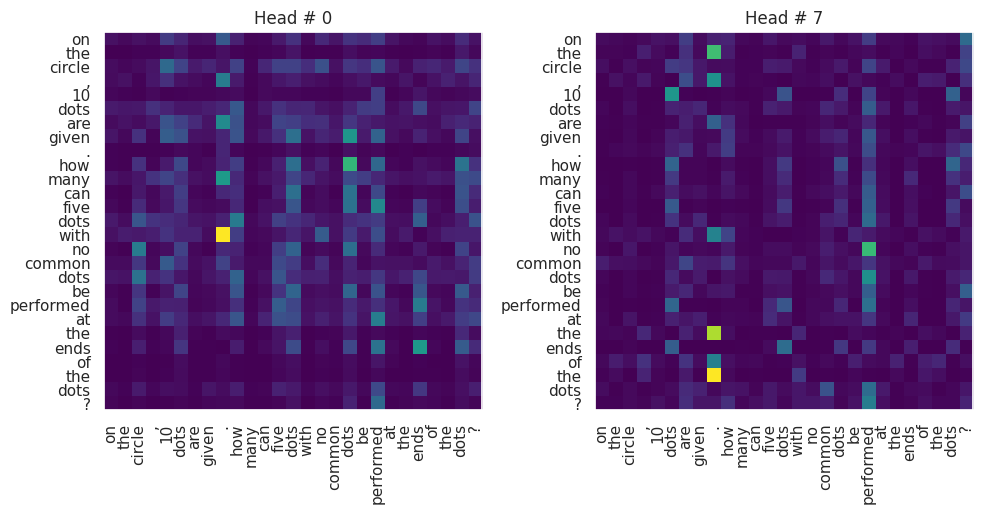

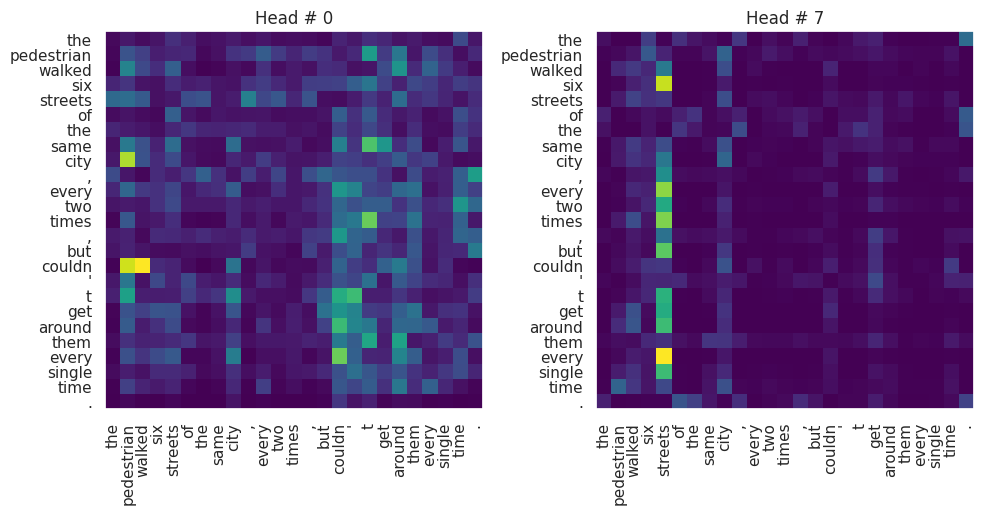

In [240]:
text1 = test_dataset['text'][3]
text2 = test_dataset['text'][4]
model = mathbert_finetuned

draw_first_layer_attention_maps([0, 7], text1, model, "tbs17/MathBert")
draw_first_layer_attention_maps([0, 7], text2, model, "tbs17/MathBert")

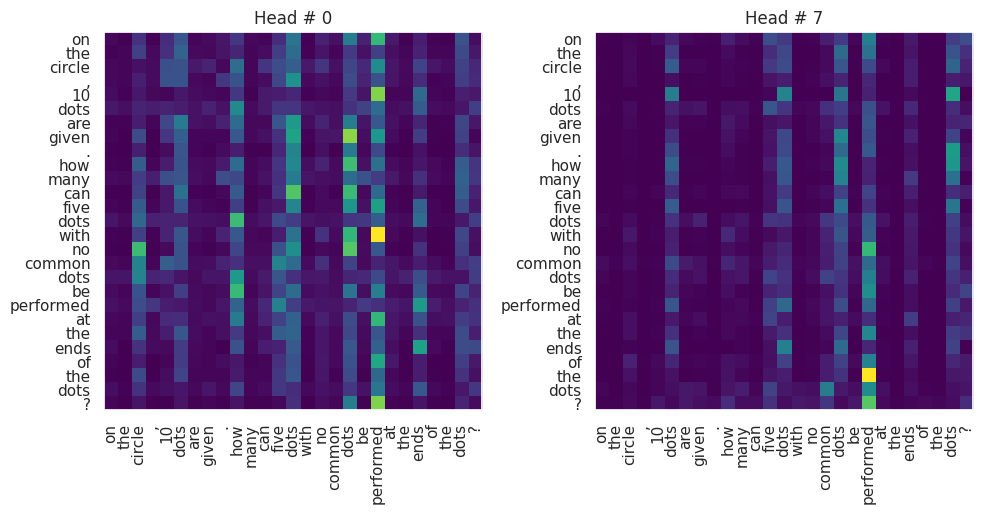

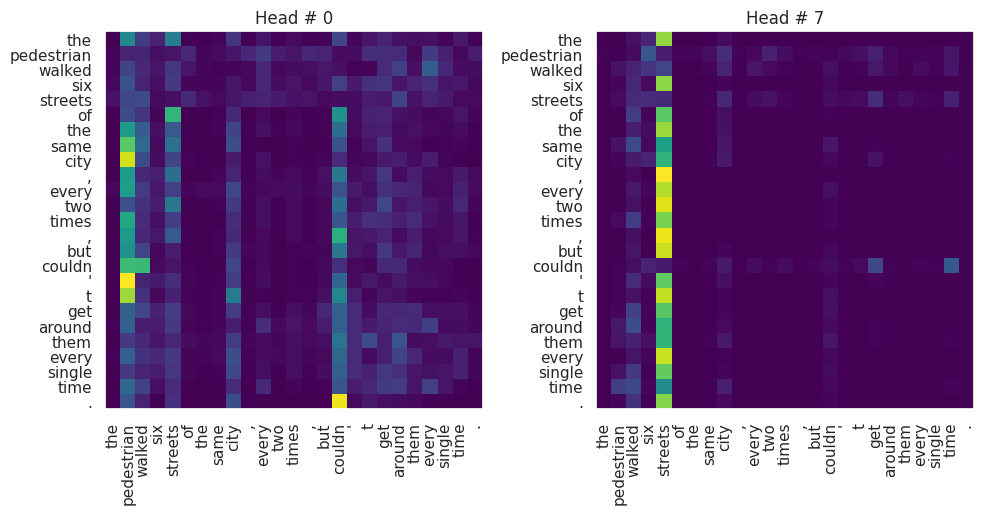

In [239]:
text1 = test_dataset['text'][3]
text2 = test_dataset['text'][4]
model = mathbert_finetuned_with_freezed_backbone

draw_first_layer_attention_maps([0, 7], text1, model, "tbs17/MathBert")
draw_first_layer_attention_maps([0, 7], text2, model, "tbs17/MathBert")

Разница заметна на картах моделей с размороженным бэкбоуном - у RuBert диагональ стала менее выражена - модель смотрит не только на соседние токены, но пытается найти более сложные закономерности
